In [9]:
# import libraries
import os
import glob
import seaborn as sns
import matplotlib.pyplot as plt
import pandas as pd

# load directories
from hbn.constants import Defaults
from hbn.visualization import visualize as vis
from hbn.features.build_features import _index_dataframe_by_columns_values

import plotly.io as pio
pio.renderers.default = 'notebook'

%load_ext autoreload
%autoreload 2

import warnings
warnings.filterwarnings('ignore')


The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


In [21]:
### DEFINE VARIABLES ###

model_parent = 'adhd_april'

models = glob.glob(os.path.join(Defaults.MODEL_DIR, model_parent, '*'))


### Load Results

In [22]:

# load model results
data = pd.DataFrame()
for model in models:
    # read model summary into pd dataframe
    df = pd.read_csv(os.path.join(model, 'model-summary.csv'), engine='python')

    df['features'] = df['feat_spec_name'].str.replace('features-', '')
    df['features'] = df['features'].str.replace('-remove-total-scores', '')
    df['demos'] = df['spec_name'].str.replace('participants-adhd-', '').str.replace('-spec', '')
    df['model_dir'] = model
    # df['readers'] = df['Age_round'].map({'6_7_8': 'early', '9_10': 'emerging', '11_12_13_14_15_16_17_18': 'fluent'})

    # append dataframe
    data = pd.concat([data, df])

    

### Firstlevel models (classifiers)

Best classifier is `RandomForestClassifier` across `Child` `Parent` and `Teacher` assessments

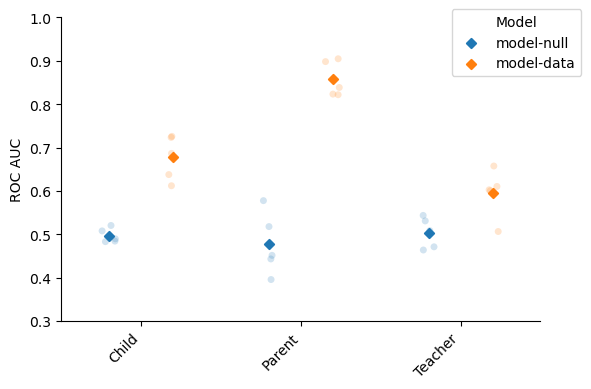

In [17]:
columns = ['clf', 'data', 'Sex', 'PreInt_Demos_Fam,Child_Race_cat', 'Age_round', 'model_type', 'features']
values_list = [
    ['RandomForestClassifier'],
    ['model-data', 'model-null'],
    ['male_female'],
    ['all'],
    ['5_6_7_8_9_10_11_12_13_14_15_16_17_18_19_20_21'],
    ['secondlevel'],
    ['Child', 'Parent', 'Teacher']
               ]

df_filter = _index_dataframe_by_columns_values(dataframe=data, columns=columns, values_list=values_list)

fig = vis.pointplot(
            data=df_filter, 
            y='roc_auc_score', 
            x='features', 
            hue='data', 
            fig_title='',
            legend_title='Model', 
            join_lines=False,
            ylabel='ROC AUC', 
            xlabel=None, 
            markers="D",
            scale=0.7,
            figsize=(6,4)
            )

fig.figure.savefig(os.path.join(Defaults.FIG_DIR, 'assessments-Child-Teacher-Parent-multipleclassifiers.png'), bbox_inches='tight')


## Compare Child-Parent-Teacher Models `RandomForestClassifier`

In [23]:
#### STATS ####

from scipy import stats as sp

child = df_filter[df_filter['features']=='Child']
parent = df_filter[df_filter['features']=='Parent']
teacher = df_filter[df_filter['features']=='Teacher']

# calculate the F test - one way ANOVA
result = sp.f_oneway(child['roc_auc_score'], parent['roc_auc_score'], teacher['roc_auc_score'])
print(f'F test for evaluation between males and females: {result}')


F test for evaluation between males and females: F_onewayResult(statistic=nan, pvalue=nan)


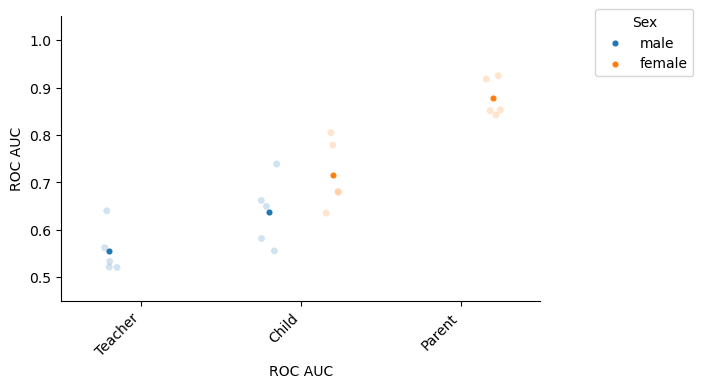

In [27]:
columns = ['clf', 'data', 'Sex', 'PreInt_Demos_Fam,Child_Race_cat', 'Age_round', 'model_type', 'features']
values_list = [
    ['RandomForestClassifier'],
    ['model-data'],
    ['male', 'female'],
    ['all'],
    ['5_6_7_8_9_10_11_12_13_14_15_16_17_18_19_20_21'],
    ['secondlevel'],
    ['Child', 'Parent', 'Teacher']
               ]

df_filter = _index_dataframe_by_columns_values(dataframe=data, columns=columns, values_list=values_list).drop_duplicates().reset_index()

fig = vis.pointplot(
    x='features', 
    y='roc_auc_score', 
    hue='Sex', 
    ylim=[0.45,1.05], 
    ylabel='ROC AUC', 
    data=df_filter, 
    fig_title='', 
    join_lines=False,
    legend_title='Sex',
    figsize=(6,4)
    )

# reordering the labels 
handles, _ = fig.figure.gca().get_legend_handles_labels() 
  
# specify order 
# order = [0,1] 
# labels = ['male', 'female']
  
# # pass handle & labels lists along with order as below 
# plt.legend([handles[i] for i in order], [labels[i] for i in order]) 

fig.figure.savefig(os.path.join(Defaults.FIG_DIR, 'assessments-Child-Teacher-Parent-male-female.png'), bbox_inches='tight')


In [26]:
#### STATS ####

from scipy import stats as sp

# calculate the F test - one way ANOVA
result = sp.f_oneway(df_filter[df_filter['Sex']=='male']['roc_auc_score'], df_filter[df_filter['Sex']=='female']['roc_auc_score'])
print(f'F test for evaluation between males and females: {result}')

# calculate the T test - paired t-test
tests = ['Child', 'Parent', 'Teacher']
for test in tests:
    df1 = df_filter[df_filter['features']==test]
    result = sp.ttest_rel(df1[df1['Sex']=='male']['roc_auc_score'], df1[df1['Sex']=='female']['roc_auc_score'], nan_policy='omit')
    print(f'T test for evaluation between males and females for {test}: {result}')


## Firstlevel models - Best Classifier - `RandomForestClassifier` - Separate models for Males and Females - All Ages - All Races


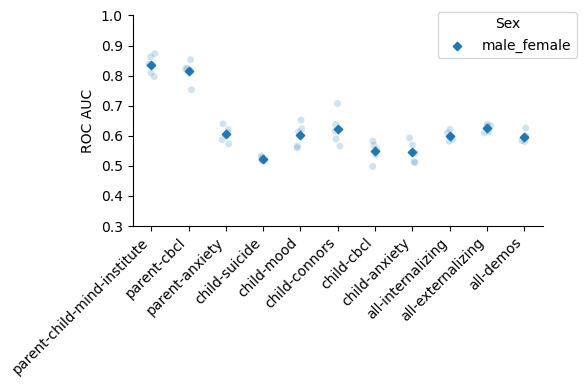

In [8]:
columns = ['clf', 'data', 'Sex', 'PreInt_Demos_Fam,Child_Race_cat', 'Age_round', 'model_type', 'features']
values_list = [
    ['RandomForestClassifier'],
    ['model-data'],
    ['male_female'],
    ['all'],
    ['5_6_7_8_9_10_11_12_13_14_15_16_17_18_19_20_21'],
    ['secondlevel'],
    ['child-connors', 'parent-child-mind-institute',
       'parent-anxiety', 'child-suicide', 'child-cbcl', 'child-anxiety',
       'parent-cbcl', 'all-demos', 'all-externalizing',
       'all-internalizing', 'child-mood']
]

df_filter = _index_dataframe_by_columns_values(dataframe=data, columns=columns, values_list=values_list).drop_duplicates().reset_index()
df_filter = df_filter.groupby(['features', 'Sex', 'splits']).first().reset_index()

df_filter['features'] = df_filter['features'].str.replace('Child-', '')

fig = vis.pointplot(
            data=df_filter.sort_values(by=['features'], ascending=False), 
            y='roc_auc_score', 
            x='features', 
            hue='Sex', 
            fig_title='',
            legend_title='Sex',
            ylabel='ROC AUC', 
            xlabel=None, 
            join_lines=False,
            markers="D",
            scale=0.6,
            figsize=(6,4)
            )

# reordering the labels 
# handles, _ = plt.gca().get_legend_handles_labels() 

# order = [0,1] 
# labels = ['male', 'female']
  
# # pass handle & labels lists along with order as below 
# plt.legend([handles[i] for i in order], [labels[i] for i in order]) 

fig.figure.savefig(os.path.join(Defaults.FIG_DIR, 'reading-all-measures-male-female.png'), bbox_inches='tight')

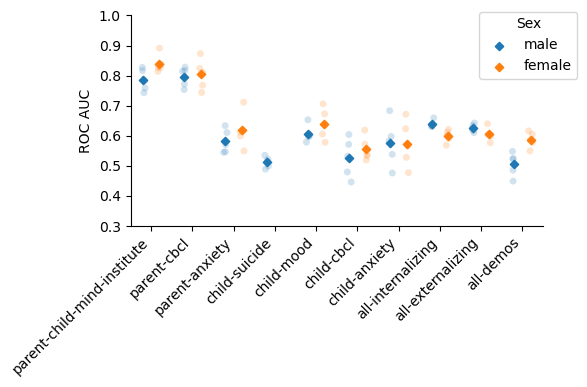

In [19]:
columns = ['clf', 'data', 'Sex', 'PreInt_Demos_Fam,Child_Race_cat', 'Age_round', 'model_type', 'features']
values_list = [
    ['RandomForestClassifier'],
    ['model-data'],
    ['male', 'female'],
    ['all'],
    ['5_6_7_8_9_10_11_12_13_14_15_16_17_18_19_20_21'],
    ['secondlevel'],
    ['child-connors', 'parent-child-mind-institute',
       'parent-anxiety', 'child-suicide', 'child-cbcl', 'child-anxiety',
       'parent-cbcl', 'all-demos', 'all-externalizing',
       'all-internalizing', 'child-mood']
]

df_filter = _index_dataframe_by_columns_values(dataframe=data, columns=columns, values_list=values_list).drop_duplicates().reset_index()
df_filter = df_filter.groupby(['features', 'Sex', 'splits']).first().reset_index()

fig = vis.pointplot(
            data=df_filter.sort_values(by=['features'], ascending=False), 
            y='roc_auc_score', 
            x='features', 
            hue='Sex', 
            fig_title='',
            legend_title='Sex',
            ylabel='ROC AUC', 
            xlabel=None, 
            join_lines=False,
            markers="D",
            scale=0.6,
            figsize=(6,4)
            )

# reordering the labels 
# handles, _ = plt.gca().get_legend_handles_labels() 

# order = [0,1] 
# labels = ['male', 'female']
  
# # pass handle & labels lists along with order as below 
# plt.legend([handles[i] for i in order], [labels[i] for i in order]) 

fig.figure.savefig(os.path.join(Defaults.FIG_DIR, 'reading-all-measures-male-female.png'), bbox_inches='tight')

In [15]:
#### STATS ####

from scipy import stats as sp

gender_groups = df_filter.groupby(['Sex', 'features'])['roc_auc_score']
gender_means = gender_groups.mean().reset_index()

# calculate the F test - one way ANOVA
result = sp.f_oneway(gender_means[gender_means['Sex']=='male']['roc_auc_score'], gender_means[gender_means['Sex']=='female']['roc_auc_score'])
# result = sp.f_oneway(df_filter[df_filter['Sex']=='male']['roc_auc_score'], df_filter[df_filter['Sex']=='female']['roc_auc_score'])
print(f'F test for evaluation between males and females: {result}')

# calculate the T test - paired t-test
tests = ['language', 'production',
       'intelligence', 'executive-function',
       'reading', 'emotional-status', 'cbcl']
for test in tests:
    df1 = df_filter[df_filter['features']==test]
    result = sp.ttest_rel(df1[df1['Sex']=='male']['roc_auc_score'], df1[df1['Sex']=='female']['roc_auc_score'], nan_policy='omit')
    print(f'T test for evaluation between males and females for {test}: {result}')


F test for evaluation between males and females: F_onewayResult(statistic=0.06274438195349553, pvalue=0.8145497457448159)
T test for evaluation between males and females for language: TtestResult(statistic=nan, pvalue=nan, df=nan)
T test for evaluation between males and females for production: TtestResult(statistic=nan, pvalue=nan, df=nan)
T test for evaluation between males and females for intelligence: TtestResult(statistic=nan, pvalue=nan, df=nan)
T test for evaluation between males and females for executive-function: TtestResult(statistic=nan, pvalue=nan, df=nan)
T test for evaluation between males and females for reading: TtestResult(statistic=nan, pvalue=nan, df=nan)
T test for evaluation between males and females for emotional-status: TtestResult(statistic=nan, pvalue=nan, df=nan)
T test for evaluation between males and females for cbcl: TtestResult(statistic=nan, pvalue=nan, df=nan)


## Developmental Stages

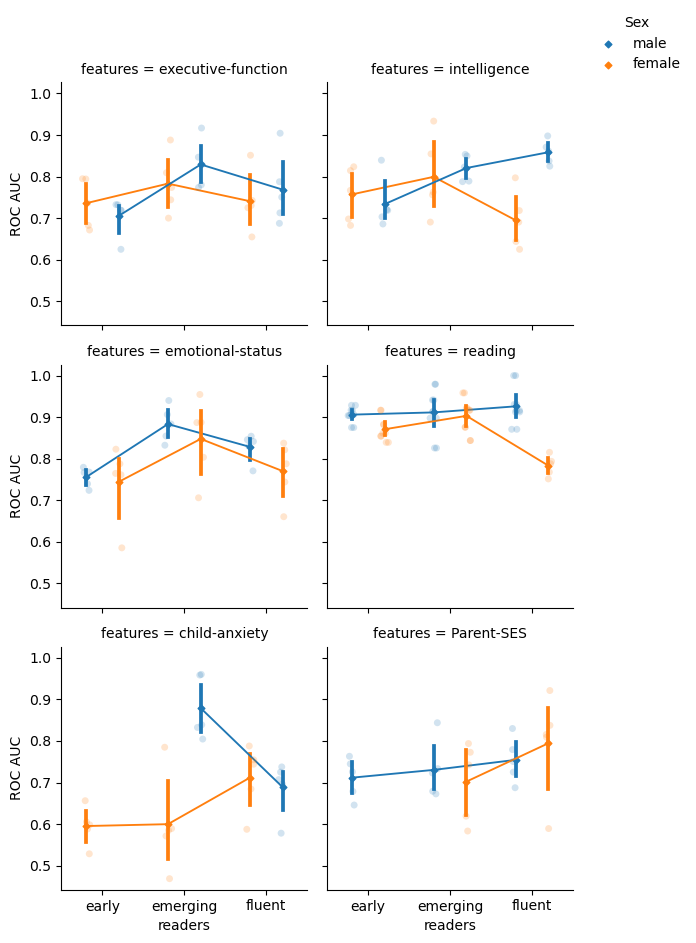

In [38]:
columns = ['clf', 'data', 'Sex', 'PreInt_Demos_Fam,Child_Race_cat', 'Age_round', 'model_type', 'features']
values_list = [
    ['RandomForestClassifier'],
    ['model-data'],
    ['male', 'female'],
    ['all'],
    ['6_7_8', '9_10', '11_12_13_14_15_16_17_18'],
    ['secondlevel'],
    ['Child-reading', 'Child-intelligence', 'Child-emotional-status', 
     'Child-executive-function', 'child-anxiety', 'Parent-SES']
    ]

# do filtering
df_filter = _index_dataframe_by_columns_values(dataframe=data, columns=columns, values_list=values_list)

df_filter['features'] = df_filter['features'].str.replace('Child-', '')

color_dict = {"male": (0.12156862745098039, 0.4666666666666667, 0.7058823529411765), 
              "female": (1.0, 0.4980392156862745, 0.054901960784313725)}


g = sns.FacetGrid(df_filter.sort_values(by='readers'), col="features", margin_titles=False, col_wrap=2)
g.map_dataframe(sns.stripplot, x="readers", y="roc_auc_score", hue='Sex', dodge=True, alpha=.2, legend=False, palette=color_dict)
g.map_dataframe(sns.pointplot, x="readers", y="roc_auc_score", hue='Sex', 
                markers="D", scale=0.5, palette=color_dict, join=True, dodge=0.4,  linestyles=["-", "-"])
g.set_ylabels('ROC AUC')
g.despine()
g.fig.subplots_adjust(right=0.8)
g.add_legend(loc='upper right', fontsize=10, bbox_to_anchor=(1, 1.05), title='Sex', label_order=['male', 'female'])
g.tight_layout()

g.figure.savefig(os.path.join(Defaults.FIG_DIR, f'all-models-readers-ages-male-female.png'), bbox_inches='tight')

    

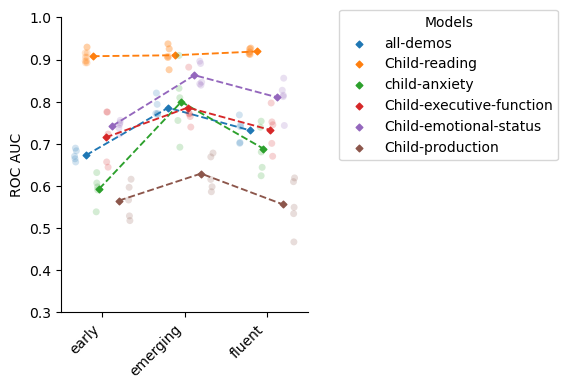

In [58]:
columns = ['clf', 'data', 'Sex', 'PreInt_Demos_Fam,Child_Race_cat', 'Age_round', 'model_type', 'features']
values_list = [
    ['RandomForestClassifier'],
    ['model-data'],
    ['male_female'],
    ['all'],
    ['6_7_8', '9_10', '11_12_13_14_15_16_17_18'],
    ['secondlevel'],
    # ['Child-reading', 'Child-intelligence', 'Child-emotional-status', 'child-anxiety', 'Child-executive-function']
    ['Child-language', 'Child-production', 
      'Child-executive-function', 'child-anxiety',
       'Child-reading', 'Child-emotional-status', 'all-demos']
    ]

# do filtering
df_filter = _index_dataframe_by_columns_values(dataframe=data, columns=columns, values_list=values_list)

fig = vis.pointplot(
            data=df_filter.sort_values(by='readers'), 
            y='roc_auc_score', 
            x='readers', 
            hue='features', 
            fig_title='',
            legend_title='Models', 
            ylabel='ROC AUC', 
            xlabel=None, 
            markers="D",
            ylim=[0.3, 1],
            scale=0.5,
            dodge=0.4,
            figsize=(6,4)
            )


fig.figure.savefig(os.path.join(Defaults.FIG_DIR, 'best-models-ages-all-participants.png'), bbox_inches='tight')

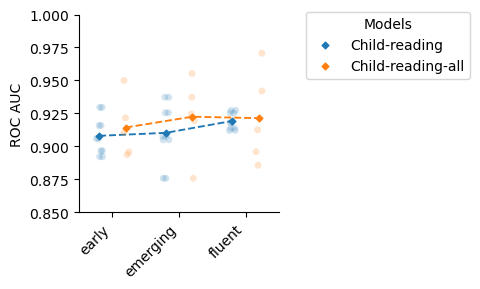

In [75]:
columns = ['clf', 'data', 'Sex', 'PreInt_Demos_Fam,Child_Race_cat', 'Age_round', 'model_type', 'features']
values_list = [
    ['RandomForestClassifier'],
    ['model-data'],
    ['male_female'],
    ['all'],
    ['6_7_8', '9_10', '11_12_13_14_15_16_17_18'],
    ['secondlevel'],
    # ['Child-reading', 'Child-intelligence', 'Child-emotional-status', 'child-anxiety', 'Child-executive-function']
    ['Child-reading', 'Child-reading-all']
    ]

# do filtering
df_filter = _index_dataframe_by_columns_values(dataframe=data, columns=columns, values_list=values_list)

fig = vis.pointplot(
            data=df_filter.sort_values(by='readers'), 
            y='roc_auc_score', 
            x='readers', 
            hue='features', 
            fig_title='',
            legend_title='Models', 
            ylabel='ROC AUC', 
            xlabel=None, 
            markers="D",
            ylim=[0.85, 1],
            scale=0.5,
            dodge=0.4,
            figsize=(5,3)
            )


fig.figure.savefig(os.path.join(Defaults.FIG_DIR, 'reading-full-reading-abridged-ages.png'), bbox_inches='tight')

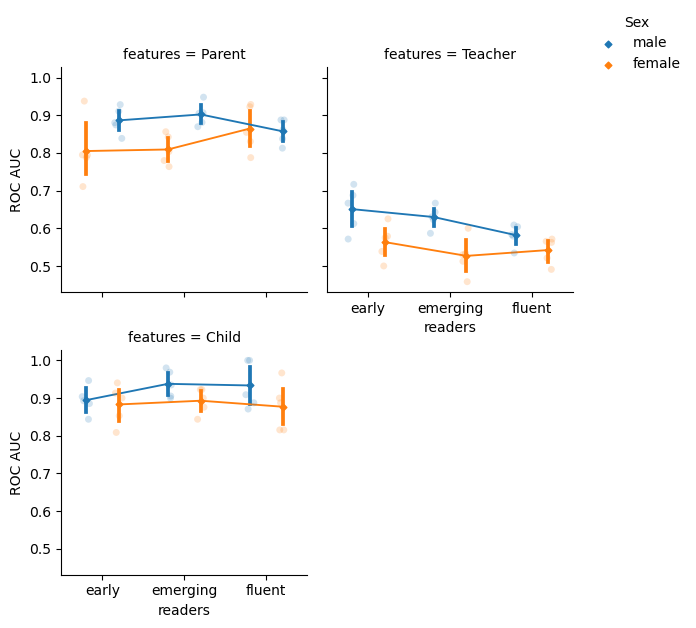

In [39]:
columns = ['clf', 'data', 'Sex', 'PreInt_Demos_Fam,Child_Race_cat', 'Age_round', 'model_type', 'features']
values_list = [
    ['RandomForestClassifier'],
    ['model-data'],
    ['male', 'female'],
    ['all'],
    ['6_7_8', '9_10', '11_12_13_14_15_16_17_18'],
    ['secondlevel'],
    ['Child', 'Parent', 'Teacher']
    ]

# do filtering
df_filter = _index_dataframe_by_columns_values(dataframe=data, columns=columns, values_list=values_list)

df_filter['features'] = df_filter['features'].str.replace('Child-', '')

color_dict = {"male": (0.12156862745098039, 0.4666666666666667, 0.7058823529411765), 
              "female": (1.0, 0.4980392156862745, 0.054901960784313725)}


g = sns.FacetGrid(df_filter.sort_values(by='readers'), col="features", margin_titles=False, col_wrap=2)
g.map_dataframe(sns.stripplot, x="readers", y="roc_auc_score", hue='Sex', dodge=True, alpha=.2, legend=False, palette=color_dict)
g.map_dataframe(sns.pointplot, x="readers", y="roc_auc_score", hue='Sex', 
                markers="D", scale=0.5, palette=color_dict, join=True, dodge=0.4,  linestyles=["-", "-"])
g.set_ylabels('ROC AUC')
g.despine()
g.fig.subplots_adjust(right=0.8)
g.add_legend(loc='upper right', fontsize=10, bbox_to_anchor=(1, 1.05), title='Sex', label_order=['male', 'female'])
g.tight_layout()

g.figure.savefig(os.path.join(Defaults.FIG_DIR, f'all-assessments-readers-ages-male-female.png'), bbox_inches='tight')

    

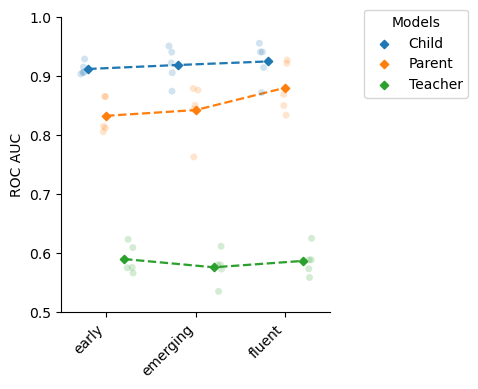

In [44]:
columns = ['clf', 'data', 'Sex', 'PreInt_Demos_Fam,Child_Race_cat', 'Age_round', 'model_type', 'features']
values_list = [
    ['RandomForestClassifier'],
    ['model-data'],
    ['male_female'],
    ['all'],
    ['6_7_8', '9_10', '11_12_13_14_15_16_17_18'],
    ['secondlevel'],
    ['Child', 'Parent', 'Teacher']
    ]

# do filtering
df_filter = _index_dataframe_by_columns_values(dataframe=data, columns=columns, values_list=values_list)

fig = vis.pointplot(
            data=df_filter.sort_values(by='readers'), 
            y='roc_auc_score', 
            x='readers', 
            hue='features', 
            fig_title='',
            legend_title='Models', 
            ylabel='ROC AUC', 
            xlabel=None, 
            markers="D",
            ylim=[0.5, 1],
            scale=0.6,
            dodge=0.4,
            figsize=(5,4)
            )


fig.figure.savefig(os.path.join(Defaults.FIG_DIR, 'best-models-ages-all-assessments.png'), bbox_inches='tight')

In [24]:
# do stats
from scipy import stats as sp

# loop through features
feat_list = ['Child-reading', 'Child-intelligence', 'Child-emotional-status', 'Child-executive-function', 'Reading-all']
for feat in feat_list:

    df1 = _index_dataframe_by_columns_values(dataframe=df_filter, columns=['features'], values_list=[[feat]])

    # calculate the F test - one way ANOVA
    result = sp.f_oneway(df1[df1['readers']=='early']['roc_auc_score'], 
                         df1[df1['readers']=='emerging']['roc_auc_score'],
                         df1[df1['readers']=='emerging']['roc_auc_score'])
    print(f'F test for evaluation between early, emerging and fluent readers for {feat}: {result}')

F test for evaluation between early, emerging and fluent readers for Child-reading: F_onewayResult(statistic=nan, pvalue=nan)
F test for evaluation between early, emerging and fluent readers for Child-intelligence: F_onewayResult(statistic=nan, pvalue=nan)
F test for evaluation between early, emerging and fluent readers for Child-emotional-status: F_onewayResult(statistic=nan, pvalue=nan)
F test for evaluation between early, emerging and fluent readers for Child-executive-function: F_onewayResult(statistic=nan, pvalue=nan)
F test for evaluation between early, emerging and fluent readers for Reading-all: F_onewayResult(statistic=nan, pvalue=nan)


In [19]:
# do stats
from scipy import stats as sp

# calculate the F test - one way ANOVA
result = sp.f_oneway(df_filter[df_filter['readers']=='early']['roc_auc_score'], 
                        df_filter[df_filter['readers']=='emerging']['roc_auc_score'],
                        df_filter[df_filter['readers']=='emerging']['roc_auc_score'])
print(f'F test for evaluation between early, emerging and fluent readers: {result}')

F test for evaluation between early, emerging and fluent readers: F_onewayResult(statistic=2.3366598714395854, pvalue=0.10393845204998255)


## Feature Importances for Best Models

['/om2/user/maedbh/hbn_data/interim/models/reading_april/2024-04-01_17-11-00-86_secondlevel'
 '/om2/user/maedbh/hbn_data/interim/models/reading_april/2024-04-01_17-11-01-22_secondlevel'
 '/om2/user/maedbh/hbn_data/interim/models/reading_april/2024-04-01_17-11-01-50_secondlevel'
 '/om2/user/maedbh/hbn_data/interim/models/reading_april/2024-04-01_17-11-01-60_secondlevel'
 '/om2/user/maedbh/hbn_data/interim/models/reading_april/2024-04-01_17-11-01-64_secondlevel'
 '/om2/user/maedbh/hbn_data/interim/models/reading_april/2024-04-01_17-11-01-98_secondlevel']


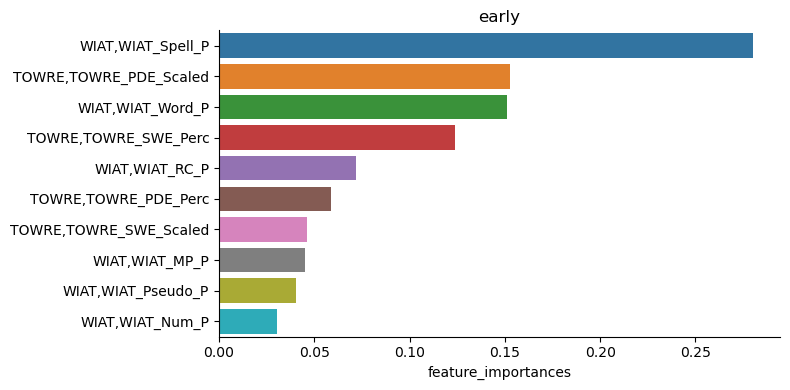

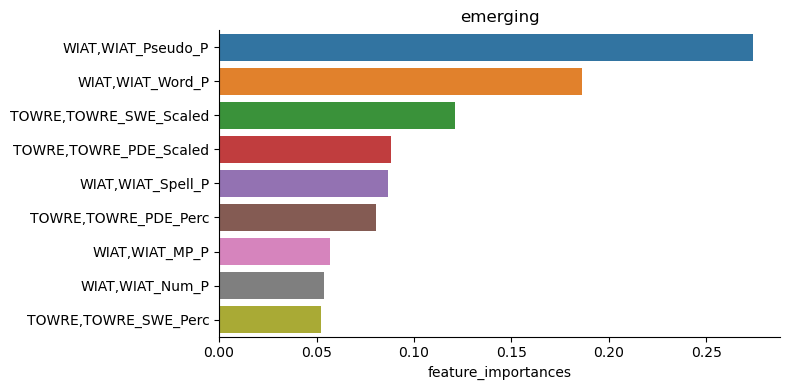

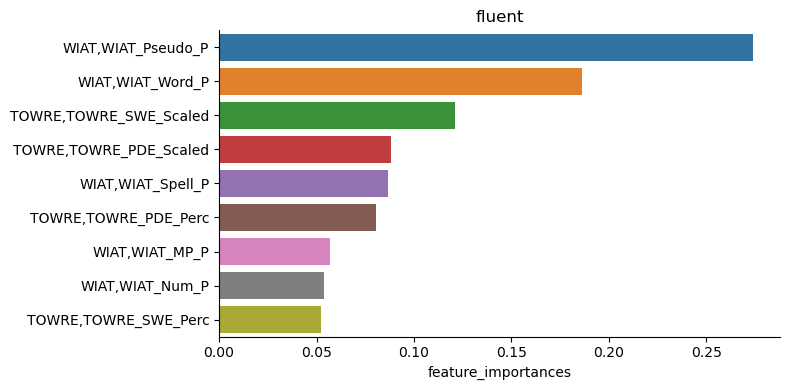

In [20]:
# select model name based on conditionals

columns = ['clf', 'data', 'Sex', 'PreInt_Demos_Fam,Child_Race_cat', 'Age_round', 'model_type', 'features']
values_list = [
    ['RandomForestClassifier'],
    ['model-data'],
    ['male_female'],
    ['all'],
    ['6_7_8', '9_10', '11_12_13_14_15_16_17_18'],
    ['secondlevel'],
    ['Child-reading']
    # ['Child-remove-total-scores']
    ]

df_filter = _index_dataframe_by_columns_values(dataframe=data, columns=columns, values_list=values_list)

dirs = df_filter['model_dir'].unique()
print(dirs)

for (reader, model_dir) in zip(['early', 'emerging', 'fluent'], dirs):

    # load feature importances 
    features = pd.read_csv(os.path.join(model_dir,  'feature_importance.csv'), engine='python')

    # sort values
    features = features.sort_values(by='feature_importances', ascending=False)

    # visualize feature importances
    fig = vis.barplot(data=features, top_features=25, figsize=(8,4), title=reader)
    # fig.figure.savefig(os.path.join(Defaults.FIG_DIR, f'feature_importances-{reader}-Reading-all-model.png'), bbox_inches='tight')

['/om2/user/maedbh/hbn_data/interim/models/reading_march/2024-03-05_04-31-48-11'
 '/om2/user/maedbh/hbn_data/interim/models/reading_march/2024-03-05_04-31-50-83']


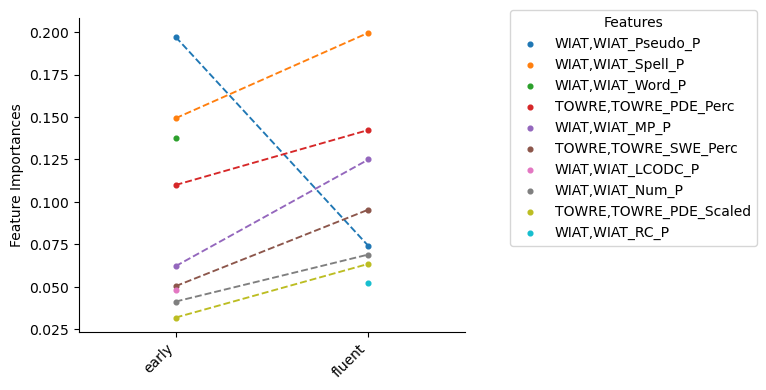

In [129]:
columns = ['clf', 'data', 'Sex', 'PreInt_Demos_Fam,Child_Race_cat', 'Age_round', 'model_type', 'features']
values_list = [
    ['RandomForestClassifier'],
    ['model-data'],
    ['male_female'],
    ['all'],
    ['6_7_8', '11_12_13_14_15_16_17_18'],
    ['firstlevel'],
    ['Child-reading']
    ]

df_filter = _index_dataframe_by_columns_values(dataframe=data, columns=columns, values_list=values_list)

dirs = df_filter['model_dir'].unique()
print(dirs)

features_all = pd.DataFrame()
for model_dir in dirs:

    # load feature importances 
    features = pd.read_csv(os.path.join(model_dir,  'feature_importance.csv'), engine='python')

    # sort values
    features = features.sort_values(by='feature_importances', ascending=False)

    # concat features
    features_all = pd.concat([features_all, features])

# remap age -> readers
features_all['readers'] = features_all['Age_round'].map({'6_7_8': 'early', '9_10': 'emerging', '11_12_13_14_15_16_17_18': 'fluent'})

# remove `numeric__`
features_all['feature_importances_names'] = features_all['feature_importances_names'].str.replace('numeric__', '')

# only take top features
features_all = features_all[features_all['top_features']==True]

fig = vis.pointplot(data=features_all, 
            y='feature_importances', 
            x='readers', 
            hue='feature_importances_names',
            fig_title='', 
            legend_title='Features', 
            ylim=None, 
            xlabel=None,  
            ylabel='Feature Importances', 
            markers="o",
            linestyles="--",
            join_lines=True,
            scale=0.5,
            alpha=0,
            dodge=False,
            figsize=(8,4)
            )

# fig = plt.gcf()
fig.figure.savefig(os.path.join(Defaults.FIG_DIR, f'feature_importances-readers-Reading-all-model.png'), bbox_inches='tight')

['/om2/user/maedbh/hbn_data/interim/models/reading_march/2024-03-04_16-08-12-21_secondlevel'
 '/om2/user/maedbh/hbn_data/interim/models/reading_march/2024-03-04_16-08-12-87_secondlevel'
 '/om2/user/maedbh/hbn_data/interim/models/reading_march/2024-03-05_16-16-34-50_secondlevel'
 '/om2/user/maedbh/hbn_data/interim/models/reading_march/2024-03-05_16-16-38-78_secondlevel']


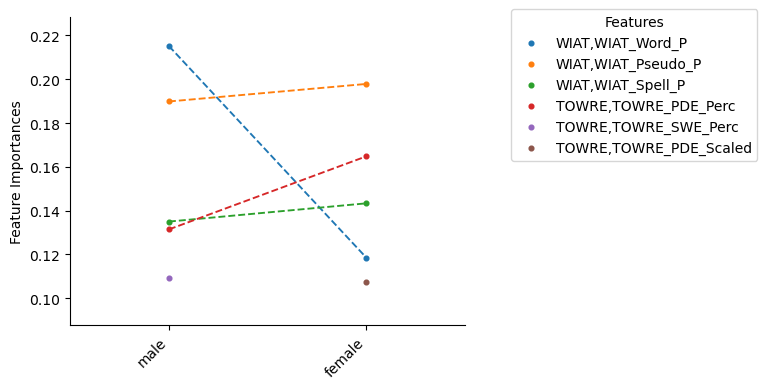

In [130]:
columns = ['clf', 'data', 'Sex', 'PreInt_Demos_Fam,Child_Race_cat', 'Age_round', 'model_type', 'features']
values_list = [
    ['RandomForestClassifier'],
    ['model-data'],
    ['male', 'female'],
    ['all'],
    ['6_7_8_9_10_11_12_13_14_15_16_17_18_19_20_21'],
    ['secondlevel'],
    ['Child-reading']
    ]

df_filter = _index_dataframe_by_columns_values(dataframe=data, columns=columns, values_list=values_list)

dirs = df_filter['model_dir'].unique()
print(dirs)

features_all = pd.DataFrame()
for model_dir in dirs:

    # load feature importances 
    features = pd.read_csv(os.path.join(model_dir,  'feature_importance.csv'), engine='python')

    # sort values
    features = features.sort_values(by='feature_importances', ascending=False)

    # concat features
    features_all = pd.concat([features_all, features])

# remap age -> readers
features_all['readers'] = features_all['Age_round'].map({'6_7_8': 'early', '9_10': 'emerging', '11_12_13_14_15_16_17_18': 'fluent'})

# remove `numeric__`
features_all['feature_importances_names'] = features_all['feature_importances_names'].str.replace('numeric__', '')

# only take top features
features_all = features_all[features_all['top_features']==True]

fig = vis.pointplot(data=features_all, 
            y='feature_importances', 
            x='Sex', 
            hue='feature_importances_names',
            fig_title='', 
            legend_title='Features', 
            ylim=None, 
            xlabel=None,  
            ylabel='Feature Importances', 
            markers="o",
            linestyles="--",
            join_lines=True,
            scale=0.5,
            alpha=0,
            dodge=False,
            figsize=(8,4)
            )

# fig = plt.gcf()
fig.figure.savefig(os.path.join(Defaults.FIG_DIR, f'feature_importances-all-readers-male-female.png'), bbox_inches='tight')

## Test Predictions

In [131]:
# select model name based on conditionals

columns = ['clf', 'data', 'Sex', 'PreInt_Demos_Fam,Child_Race_cat', 'Age_round', 'model_type', 'features']
values_list = [
    ['RandomForestClassifier'],
    ['model-data'],
    ['male_female'],
    ['all'],
    ['6_7_8_9_10_11_12_13_14_15_16_17_18_19_20_21'],
    ['secondlevel'],
    ['Child-language',
       'all-internalizing', 'all-externalizing', 'Child-production',
       'Child-intelligence', 'Child-executive-function',
       'Child-reading', 'Child-emotional-status', 'all-demos',
       'parent-child-mind-institute', 'child-cbcl']
    # ['Child-remove-total-scores']
    ]

df_filter = _index_dataframe_by_columns_values(dataframe=data, columns=columns, values_list=values_list)

dirs = df_filter['model_dir'].unique()
print(dirs)

['/om2/user/maedbh/hbn_data/interim/models/reading_march/2024-03-04_16-08-03-67_secondlevel'
 '/om2/user/maedbh/hbn_data/interim/models/reading_march/2024-03-04_16-08-04-21_secondlevel'
 '/om2/user/maedbh/hbn_data/interim/models/reading_march/2024-03-04_16-08-07-62_secondlevel'
 '/om2/user/maedbh/hbn_data/interim/models/reading_march/2024-03-04_16-08-11-13_secondlevel'
 '/om2/user/maedbh/hbn_data/interim/models/reading_march/2024-03-04_16-08-11-62_secondlevel'
 '/om2/user/maedbh/hbn_data/interim/models/reading_march/2024-03-04_16-08-12-34_secondlevel'
 '/om2/user/maedbh/hbn_data/interim/models/reading_march/2024-03-04_16-08-12-85_secondlevel'
 '/om2/user/maedbh/hbn_data/interim/models/reading_march/2024-03-04_16-08-15-45_secondlevel'
 '/om2/user/maedbh/hbn_data/interim/models/reading_march/2024-03-04_16-09-21-51_secondlevel'
 '/om2/user/maedbh/hbn_data/interim/models/reading_march/2024-03-04_16-09-42-26_secondlevel'
 '/om2/user/maedbh/hbn_data/interim/models/reading_march/2024-03-05_16

In [132]:
## load evaluation and predictions

def load_evaluation(models):
    # load model evaluation
    data_eval = pd.DataFrame()
    for model in models:
        try:
            # read model summary into pd dataframe
            df = pd.read_csv(os.path.join(model, 'model_evaluation.csv'), engine='python')

            df['model_dir'] = model
        
            # append dataframe
            
            data_eval = pd.concat([data_eval, df])
        except:
            data_eval = None
    
    return data_eval

def load_predictions(models):

    # load demographics for test participants
    df_demos = pd.read_csv(os.path.join(Defaults.INTERIM_DIR, 'phenotypes', 'all_participant_diagnoses.csv'), engine='python')
    df_grouped = df_demos.groupby('Identifiers')
    first_instances = df_grouped.head(1)

    # load model predictions
    data_pred = pd.DataFrame()
    for model in models:

        # read model summary into pd dataframe
        df = pd.read_csv(os.path.join(model, 'model_predictions.csv'), engine='python')
        df['model_dir'] = model

        # load participant index
        df_index = pd.read_csv(os.path.join(model, 'participant_index.csv'), engine='python')

        df_part = df_index[df_index['split']=='test'].reset_index(drop=True)
        cols_to_keep = [col for col in df_part.columns if 'DX_Cat_Name' not in col]

        df_merged = pd.concat([df, df_part[cols_to_keep]], axis=1)
        df_merged_demos = first_instances.merge(df_merged, on='Identifiers')
    
        # append dataframe
        data_pred = pd.concat([data_pred, df_merged_demos]).reset_index(drop=True)
    
    # add new col
    data_pred['correct_prediction'] = data_pred['y_pred']==data_pred['y_test']

    

    return data_pred

In [134]:
# # load evaluation
# df_eval = load_evaluation(models=dirs)

# # load predictions
# df_pred = load_predictions(models=dirs)

<Axes: xlabel='y_pred_prob_1', ylabel='Count'>

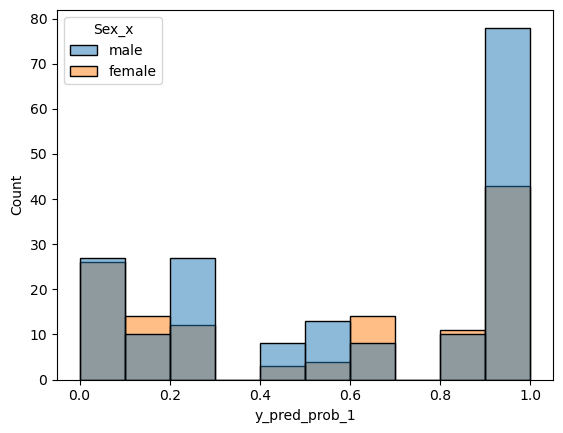

In [8]:
columns = ['Sex_x']
values_list = [
               ['male', 'female'],
               ]

df_filter = _index_dataframe_by_columns_values(dataframe=df_pred, columns=columns, values_list=values_list)


sns.histplot(data=df_filter, x='y_pred_prob_1', hue='Sex_x')

<Axes: xlabel='Age_round_x', ylabel='y_pred_prob_1'>

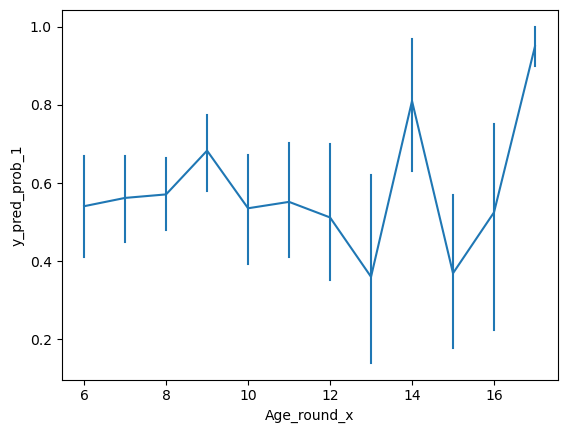

In [20]:

sns.lineplot(x='Age_round_x', y='y_pred_prob_1',  data=df_filter, err_style='bars')


